In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

# ============================================================
# 1. FIND DATABASE FILE
# ============================================================

DB_PATH = "data/raw/book_to_movie.db"

if not os.path.exists(DB_PATH):
    DB_PATH = "../data/raw/book_to_movie.db"

if not os.path.exists(DB_PATH):
    print("Database not found. Current directory:", os.getcwd())
    print("Files in current directory:", os.listdir("."))
    raise FileNotFoundError("Could not find book_to_movie.db")

print(f"✅ Database found at: {DB_PATH}")


✅ Database found at: ../data/raw/book_to_movie.db


In [9]:
print("\nLoading data from database...")
conn = sqlite3.connect(DB_PATH)

# Show table columns
cursor = conn.cursor()
cursor.execute("PRAGMA table_info(movies)")
movie_cols = [col[1] for col in cursor.fetchall()]
print("Movies columns:", movie_cols)

cursor.execute("PRAGMA table_info(books)")
book_cols = [col[1] for col in cursor.fetchall()]
print("Books columns:", book_cols)

# Load data
movies_df = pd.read_sql_query("SELECT * FROM movies", conn)
books_df = pd.read_sql_query("SELECT * FROM books", conn)
conn.close()

print(f"\nMovies: {movies_df.shape[0]} rows, {movies_df.shape[1]} columns")
print(f"Books: {books_df.shape[0]} rows, {books_df.shape[1]} columns")



Loading data from database...
Movies columns: ['title', 'release_date', 'popularity', 'vote_count']
Books columns: ['title', 'author', 'publisher', 'rating', 'voters_count', 'into_movie']

Movies: 4000 rows, 4 columns
Books: 30005 rows, 6 columns


In [10]:
# ============================================================
# 4. SUMMARY STATISTICS
# ============================================================

print("\nMovies - Numeric columns:")
print(movies_df.describe())

print("\nBooks - Numeric columns:")
print(books_df.describe())



Movies - Numeric columns:
        popularity    vote_count
count  4000.000000   4000.000000
mean     11.102972   2659.169750
std      17.866908   4774.681902
min       3.508900      0.000000
25%       6.736750     21.000000
50%       7.742900    371.500000
75%       9.831625   3156.500000
max     418.025700  38409.000000

Books - Numeric columns:
             rating   voters_count    into_movie
count  30005.000000   30005.000000  30005.000000
mean       4.019830   18856.494384      0.058657
std        0.391291   64886.572238      0.234985
min        0.000000       0.000000      0.000000
25%        3.810000      96.000000      0.000000
50%        4.010000    1736.000000      0.000000
75%        4.230000   10596.000000      0.000000
max        5.000000  962418.000000      1.000000


In [11]:
# ============================================================
# 5. TARGET VARIABLE ANALYSIS
# ============================================================

print("\nDistribution of into_movie:")
print(books_df['into_movie'].value_counts())
print(f"Adapted: {books_df['into_movie'].sum()} books")
print(f"Not adapted: {len(books_df) - books_df['into_movie'].sum()} books")

adapted = books_df[books_df['into_movie'] == 1]
non_adapted = books_df[books_df['into_movie'] == 0]

print(f"\nAdapted books - Rating stats:")
print(adapted['rating'].describe())

print(f"\nNon-adapted books - Rating stats:")
print(non_adapted['rating'].describe())


Distribution of into_movie:
into_movie
0    28245
1     1760
Name: count, dtype: int64
Adapted: 1760 books
Not adapted: 28245 books

Adapted books - Rating stats:
count    1760.000000
mean        3.980795
std         0.323978
min         0.000000
25%         3.800000
50%         3.970000
75%         4.140000
max         5.000000
Name: rating, dtype: float64

Non-adapted books - Rating stats:
count    28245.000000
mean         4.022262
std          0.394983
min          0.000000
25%          3.810000
50%          4.010000
75%          4.230000
max          5.000000
Name: rating, dtype: float64



Generating 2 movie distribution plots...


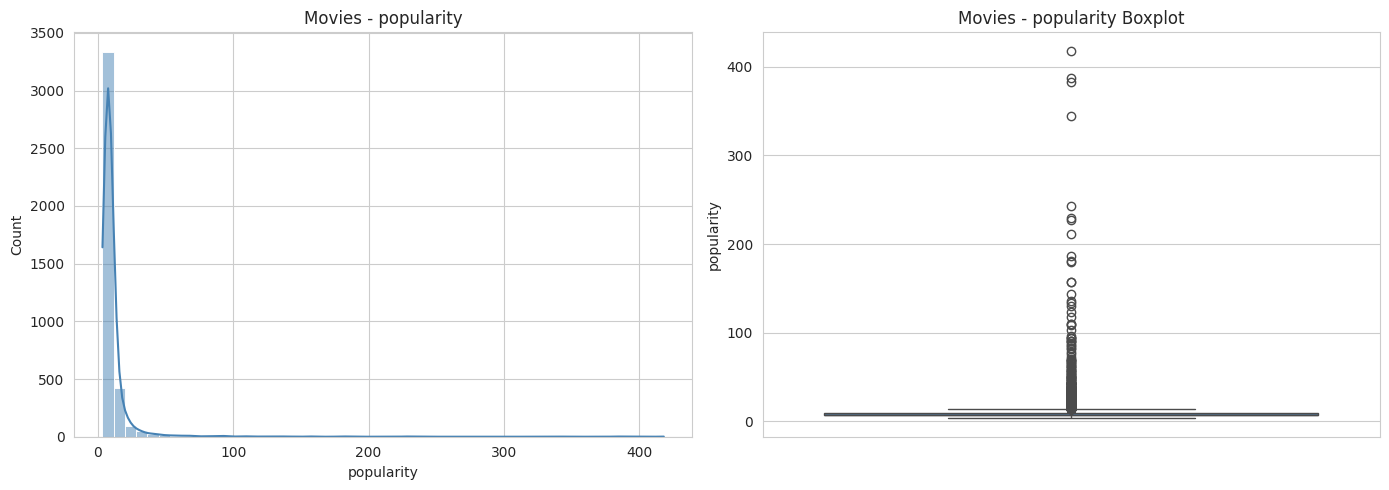

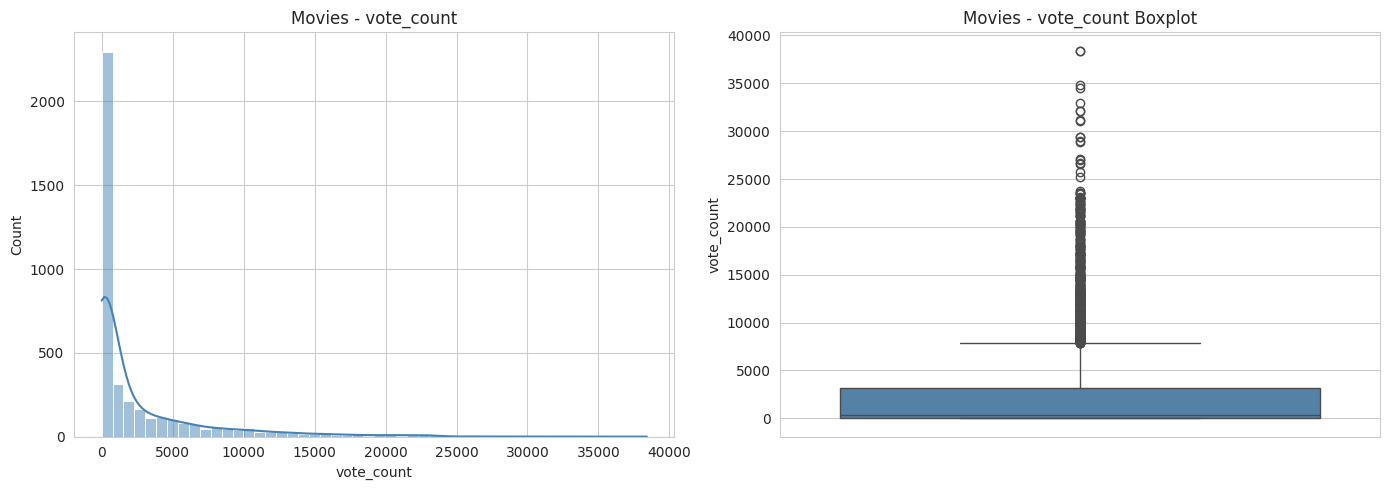


Generating 3 book distribution plots...


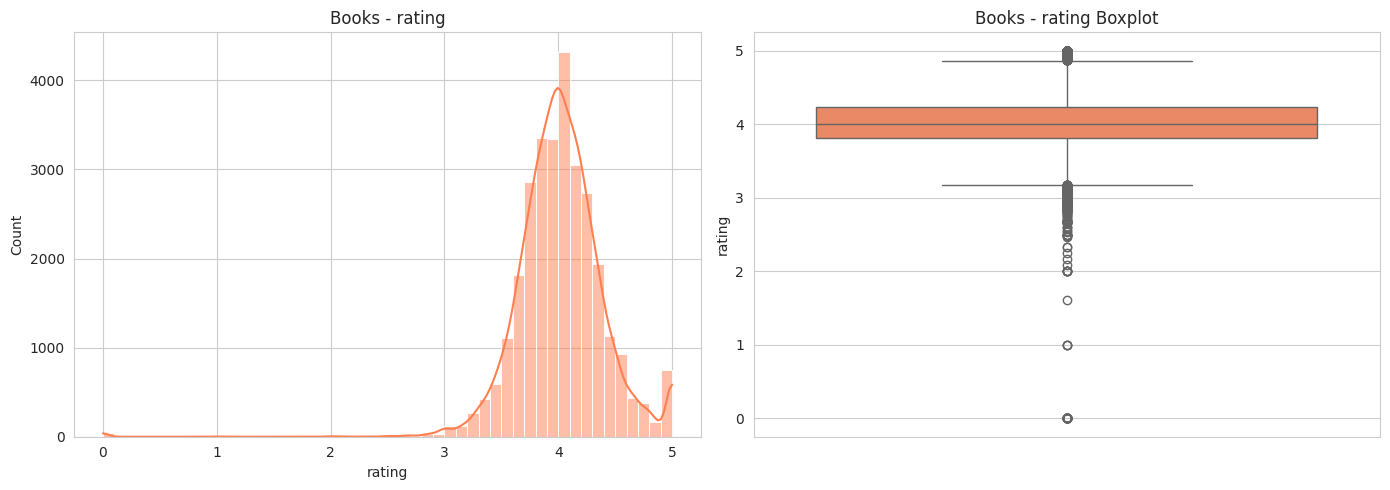

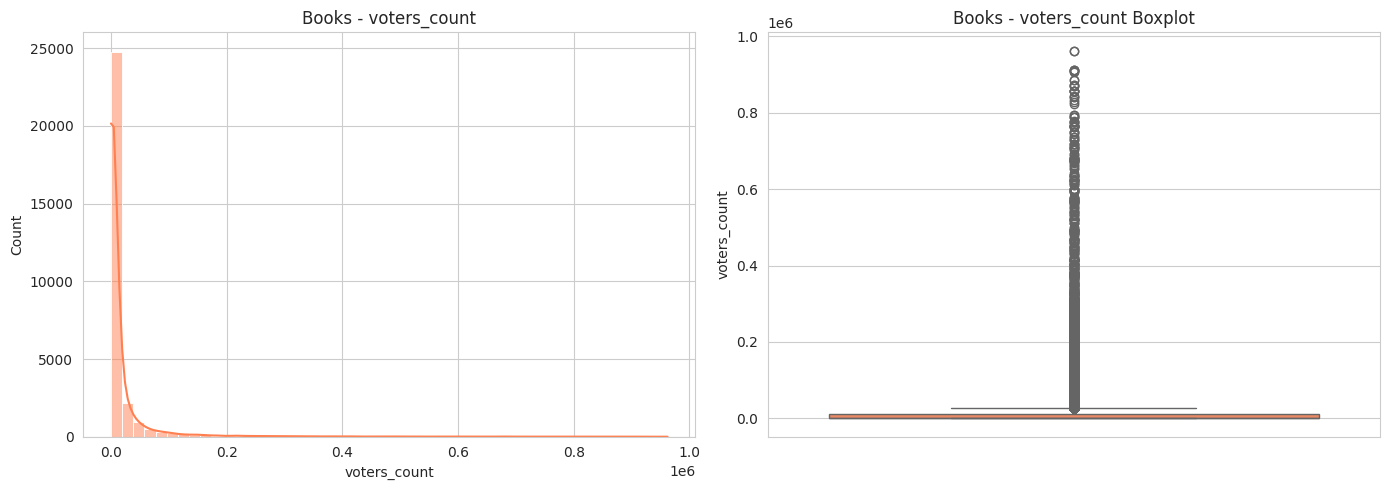

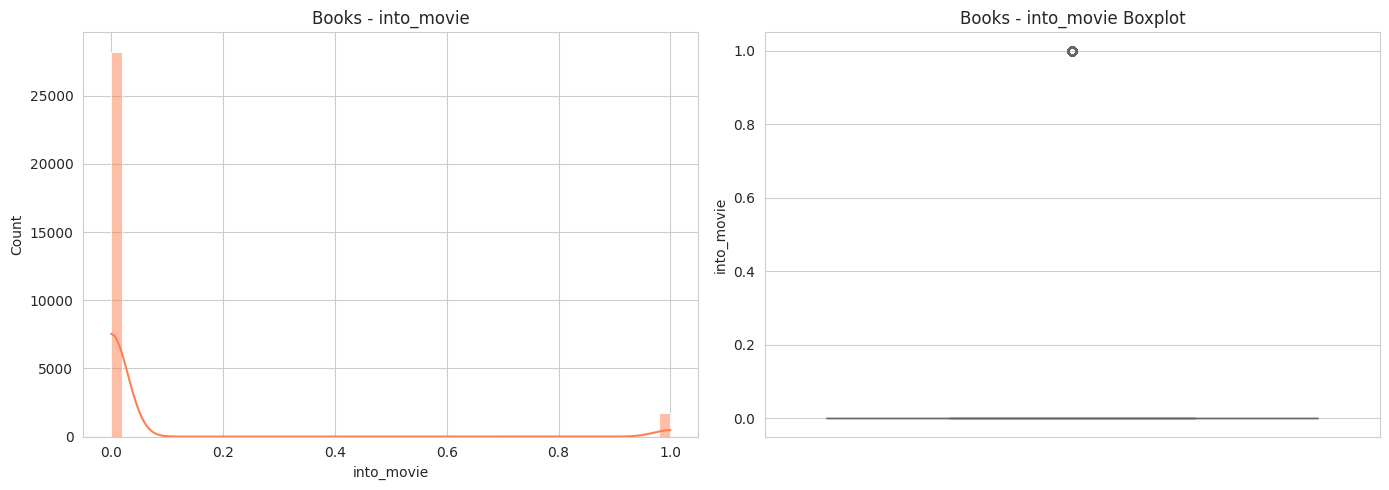

In [12]:
# ============================================================
# 6. DISTRIBUTION PLOTS
# ============================================================

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Movies - numeric columns
movie_numeric = movies_df.select_dtypes(include=[np.number]).columns
print(f"\nGenerating {len(movie_numeric)} movie distribution plots...")

for col in movie_numeric:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(movies_df[col], kde=True, ax=axes[0], bins=50, color='steelblue')
    axes[0].set_title(f'Movies - {col}')
    sns.boxplot(y=movies_df[col], ax=axes[1], color='steelblue')
    axes[1].set_title(f'Movies - {col} Boxplot')
    plt.tight_layout()
    plt.show()

# Books - numeric columns
book_numeric = books_df.select_dtypes(include=[np.number]).columns
print(f"\nGenerating {len(book_numeric)} book distribution plots...")

for col in book_numeric:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(books_df[col], kde=True, ax=axes[0], bins=50, color='coral')
    axes[0].set_title(f'Books - {col}')
    sns.boxplot(y=books_df[col], ax=axes[1], color='coral')
    axes[1].set_title(f'Books - {col} Boxplot')
    plt.tight_layout()
    plt.show()

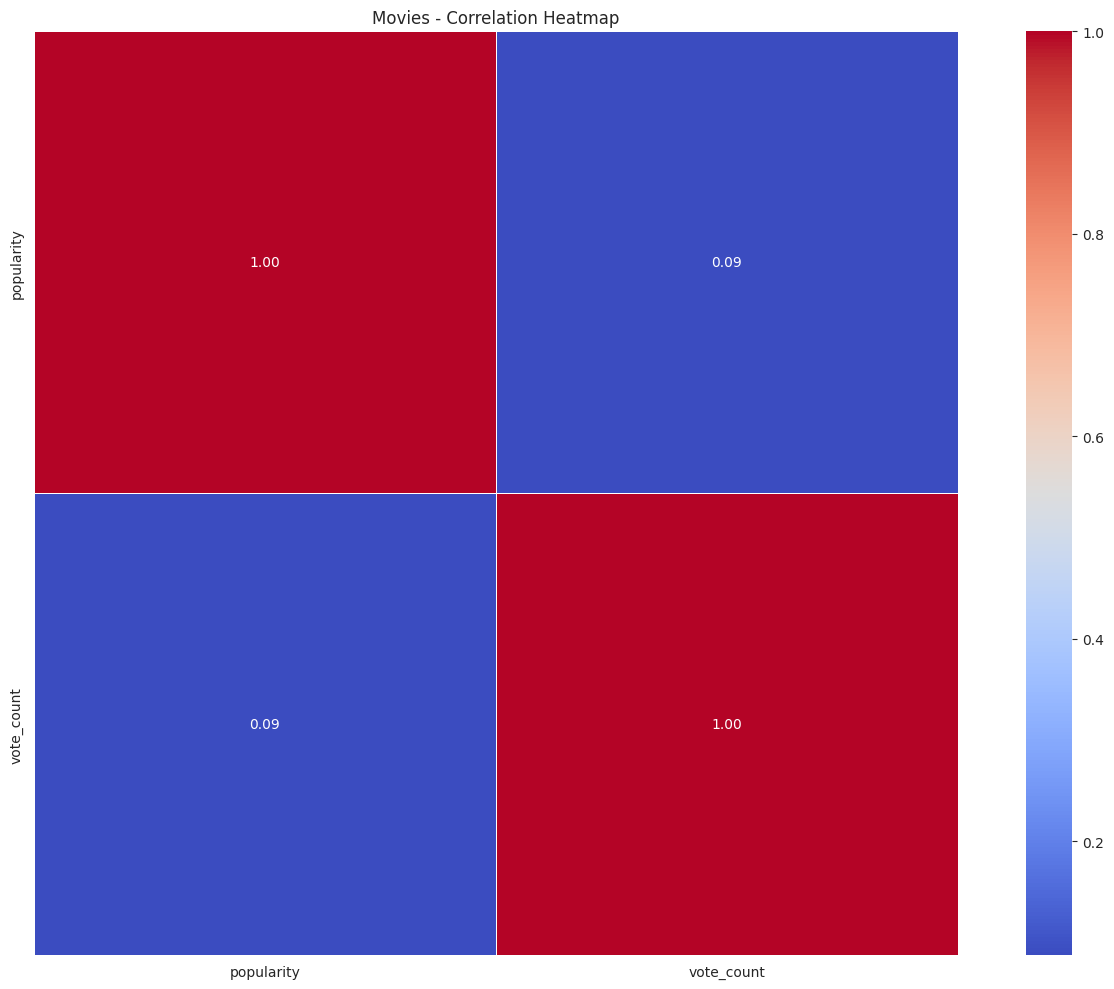

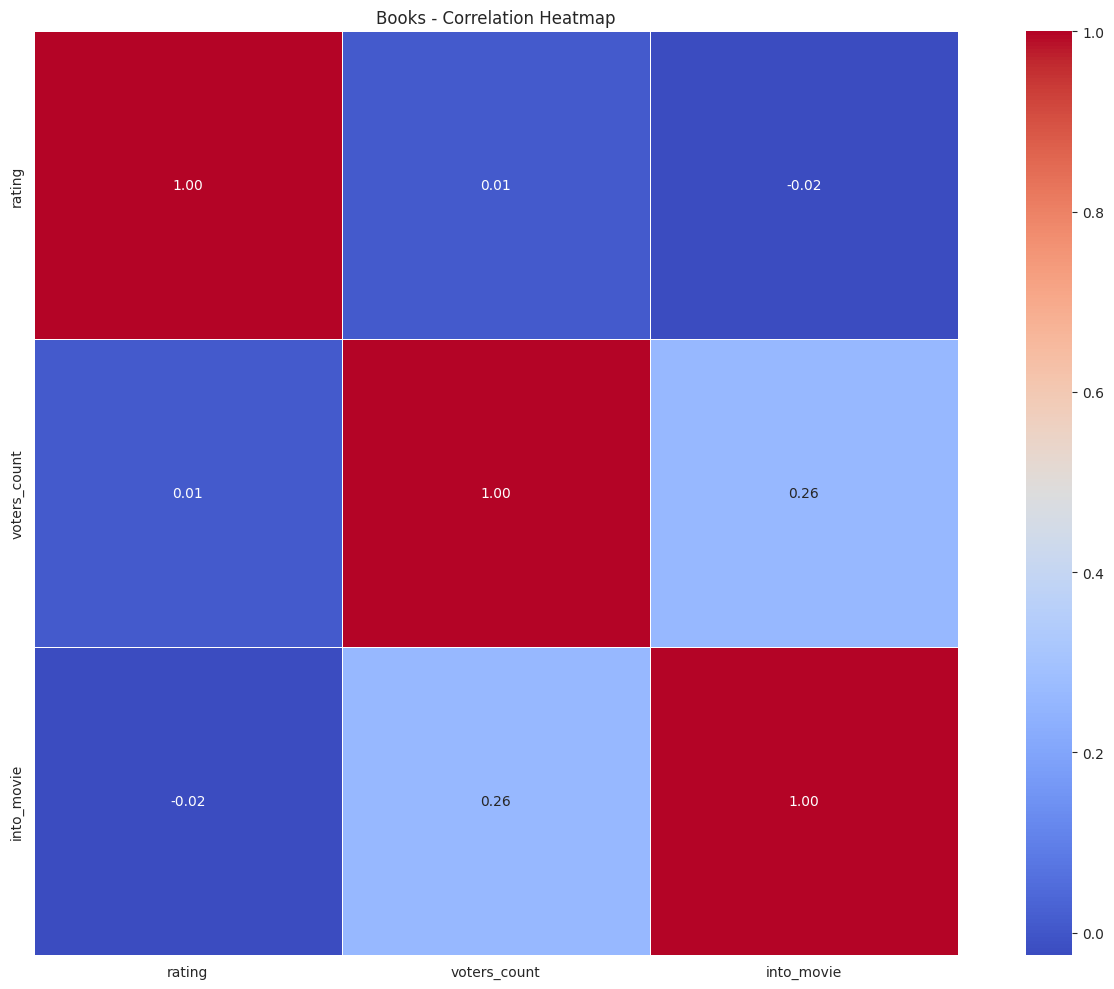

In [13]:
# ============================================================
# 7. CORRELATION HEATMAPS
# ============================================================

fig, ax = plt.subplots(figsize=(14, 10))
movie_corr = movies_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(movie_corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5, ax=ax)
ax.set_title('Movies - Correlation Heatmap')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 10))
book_corr = books_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(book_corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5, ax=ax)
ax.set_title('Books - Correlation Heatmap')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3468965/1754617926.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=books_df['into_movie'], y=books_df['rating'], ax=axes[1], palette=['red', 'green'])


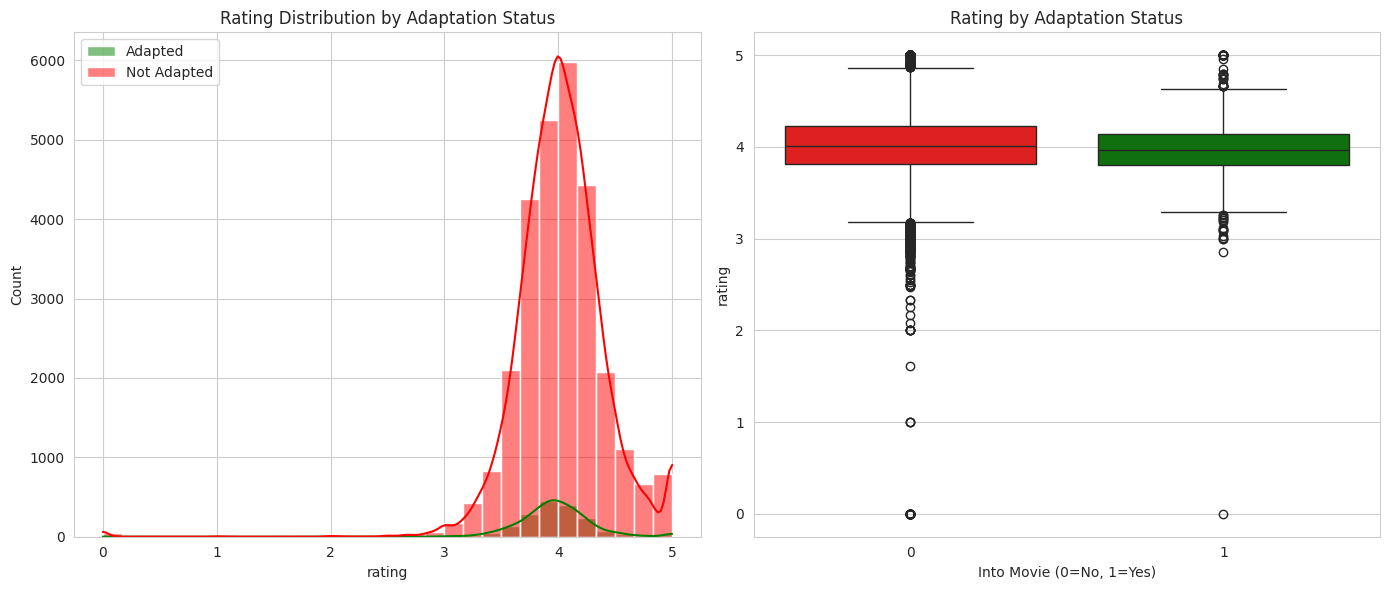

In [14]:
# ============================================================
# 8. ADAPTED VS NON-ADAPTED COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(adapted['rating'], kde=True, ax=axes[0], color='green', label='Adapted', bins=30)
sns.histplot(non_adapted['rating'], kde=True, ax=axes[0], color='red', label='Not Adapted', bins=30)
axes[0].set_title('Rating Distribution by Adaptation Status')
axes[0].legend()

sns.boxplot(x=books_df['into_movie'], y=books_df['rating'], ax=axes[1], palette=['red', 'green'])
axes[1].set_title('Rating by Adaptation Status')
axes[1].set_xlabel('Into Movie (0=No, 1=Yes)')

plt.tight_layout()
plt.show()


Data exploration here shows why further datacleaning needs to be done with this dataset as we see repeat names and differnet languages appear. 

In [15]:
# ============================================================
# 9. TOP MOVIES & BOOKS (DYNAMIC COLUMN NAMES)
# ============================================================

# Find available columns dynamically
movie_title_col = 'title' if 'title' in movies_df.columns else movies_df.columns[0]
movie_pop_col = 'popularity' if 'popularity' in movies_df.columns else movies_df.select_dtypes(include=[np.number]).columns[0]
movie_rating_col = 'vote_average' if 'vote_average' in movies_df.columns else movies_df.select_dtypes(include=[np.number]).columns[1]
movie_vote_col = 'vote_count' if 'vote_count' in movies_df.columns else movies_df.select_dtypes(include=[np.number]).columns[2]

print(f"\nUsing movie columns: title='{movie_title_col}', popularity='{movie_pop_col}'")

print("\nTop 10 most popular movies:")
display_cols = [movie_title_col, movie_pop_col]
if movie_rating_col in movies_df.columns:
    display_cols.append(movie_rating_col)
if movie_vote_col in movies_df.columns:
    display_cols.append(movie_vote_col)
print(movies_df.nlargest(10, movie_pop_col)[display_cols])

# Books
book_title_col = 'title' if 'title' in books_df.columns else books_df.columns[0]
book_author_col = 'author' if 'author' in books_df.columns else books_df.columns[1]
book_rating_col = 'rating' if 'rating' in books_df.columns else books_df.select_dtypes(include=[np.number]).columns[0]
book_vote_col = 'voters_count' if 'voters_count' in books_df.columns else books_df.select_dtypes(include=[np.number]).columns[1]

print("\nTop 10 highest rated books:")
display_cols = [book_title_col, book_author_col, book_rating_col]
if 'into_movie' in books_df.columns:
    display_cols.append('into_movie')
print(books_df.nlargest(10, book_rating_col)[display_cols])

print("\nTop 10 most voted books:")
display_cols = [book_title_col, book_author_col, book_rating_col, book_vote_col]
if 'into_movie' in books_df.columns:
    display_cols.append('into_movie')
print(books_df.nlargest(10, book_vote_col)[display_cols])



Using movie columns: title='title', popularity='popularity'

Top 10 most popular movies:
                                     title  popularity  vote_count  vote_count
0                          The Running Man    418.0257         598         598
2                    Sisu: Road to Revenge    386.9594         115         115
1                               Zootopia 2    382.4108         643         643
3   Wake Up Dead Man: A Knives Out Mystery    344.9733         697         697
17                            Worldbreaker    242.8591          15          15
5                           London Calling    229.9008          52          52
4                           Hunting Season    227.3166          33          33
7                     Avatar: Fire and Ash    211.4017          77          77
9                Five Nights at Freddy's 2    186.3681         193         193
8                               TRON: Ares    180.7952         756         756

Top 10 highest rated books:
            

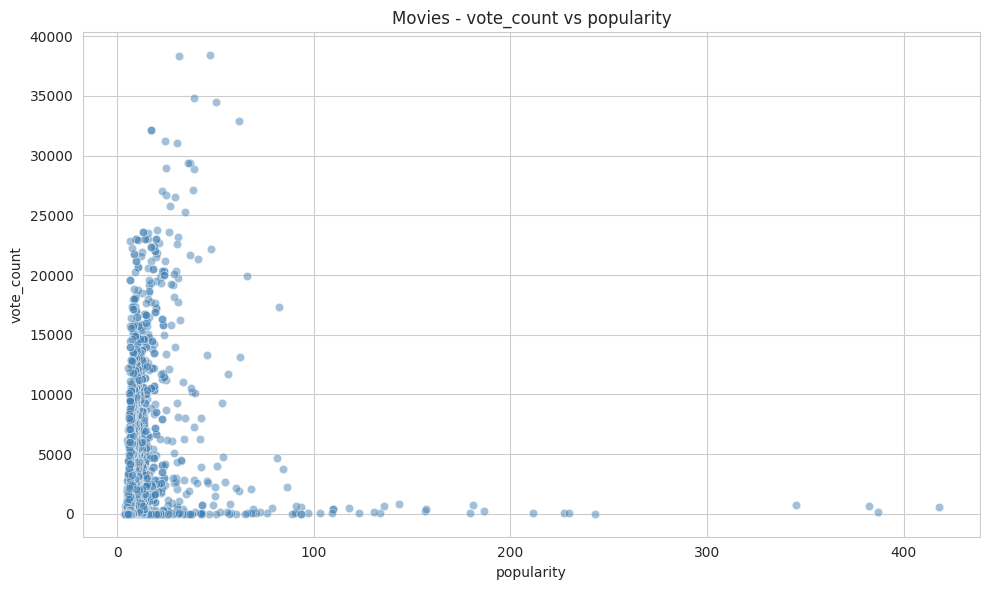


EDA complete!


In [17]:
# ============================================================
# 10. SCATTER PLOTS (DYNAMIC)
# ============================================================

if len(movies_df.select_dtypes(include=[np.number]).columns) >= 2:
    numeric_cols = movies_df.select_dtypes(include=[np.number]).columns
    x_col = numeric_cols[0]
    y_col = numeric_cols[1]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(data=movies_df, x=x_col, y=y_col, alpha=0.5, color='steelblue')
    ax.set_title(f'Movies - {y_col} vs {x_col}')
    plt.tight_layout()
    plt.show()

print("\nEDA complete!")